<a href="https://colab.research.google.com/github/ibtihalalf/Give-Me-Some-Credit-ML-Project/blob/main/GiveMeSomeCredit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Give Me Some Credit — Credit Default Prediction

This project uses machine learning to predict whether a customer is likely to experience serious financial delinquency within the next two years.

The goal is to help financial institutions identify risky customers and support better credit decision-making.

## 1. Problem Framing

### Goal
Predict whether a customer will default within two years.

### Current Non-ML Solution
A bank may manually review customer information such as income, debt ratio, and payment history.

### Application
This model can be used as a credit risk support tool.

### ML Task
This is a binary classification problem.

Target variable:
- `0`: Customer did not default
- `1`: Customer defaulted

### Why Machine Learning?
Machine learning can find patterns in customer financial behavior that simple manual rules may miss.

In [4]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and modeling
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Model evaluation
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

# Save model
import joblib

In [5]:
# Load the provided training and testing files
train_df = pd.read_csv("/Users/ebtehal/Give-Me-Some-Credit-ML-Project/data/cs-training.csv")
test_df = pd.read_csv("/Users/ebtehal/Give-Me-Some-Credit-ML-Project/data/cs-test.csv")

# Display first rows from training data
train_df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 2. Data Understanding

The dataset is already split into training and testing files.

However, the testing file does not include the true target labels.  
Because of that, model evaluation will be done using cross-validation on the training data.

In [6]:
# Check number of rows and columns
print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (150000, 12)
Testing data shape: (101503, 12)


In [7]:
# Check column names, data types, and missing values
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [8]:
# The first column is only an index column, so we remove it
train_df = train_df.drop(columns=["Unnamed: 0"])
test_df = test_df.drop(columns=["Unnamed: 0"])

# Confirm columns after dropping
train_df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


## 3. Data Quality

The dataset contains missing values,In `MonthlyIncome` and `NumberOfDependents`.

To avoid data leakage, missing values will be handled inside the machine learning pipeline using `SimpleImputer`.

In [9]:
# Count missing values in each column
train_df.isna().sum().sort_values(ascending=False)

MonthlyIncome                           29731
NumberOfDependents                       3924
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
dtype: int64

The dataset conatins 29731 missing values in MonthlyIncome and 3924 in NumberOfDependents

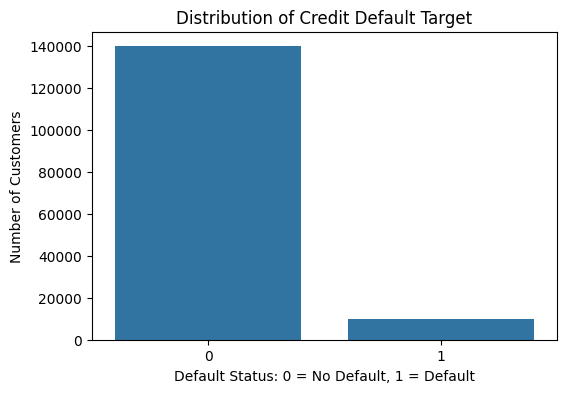

In [10]:
# Plot target distribution
plt.figure(figsize=(6, 4))

sns.countplot(x="SeriousDlqin2yrs", data=train_df)

plt.title("Distribution of Credit Default Target")
plt.xlabel("Default Status: 0 = No Default, 1 = Default")
plt.ylabel("Number of Customers")
plt.show()

## Target Distribution Observation

Most customers did not default.

This means the dataset is imbalanced, because class `0` appears much more than class `1`.

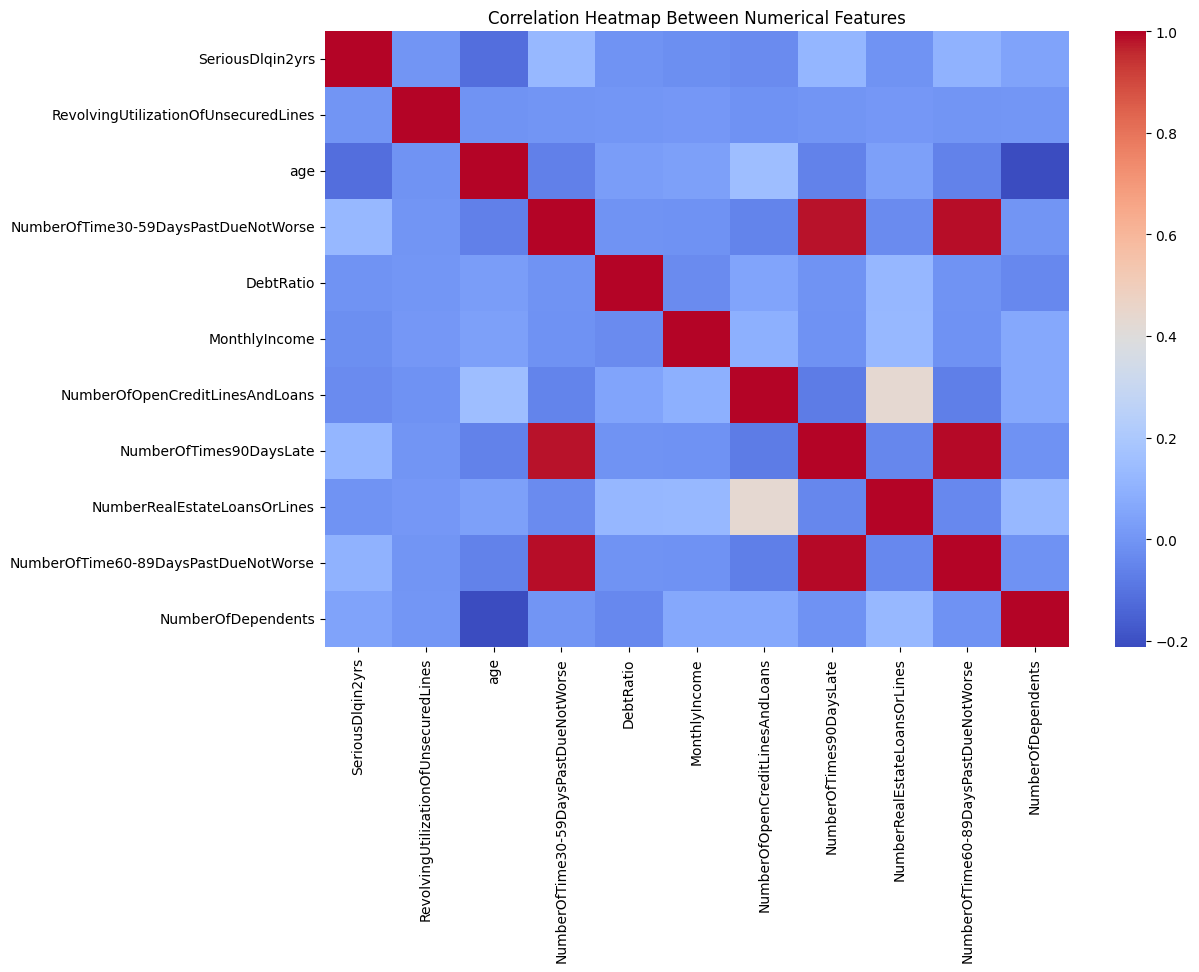

In [11]:
# Plot correlation heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    train_df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap Between Numerical Features")
plt.show()

## EDA Observation

The heatmap helps us understand relationships between numerical features.

Some features related to delinquency history may be important for predicting credit default.

## 4. Feature Engineering

No new manual features were created in this version.

However, preprocessing is applied using a pipeline:
- Missing values are filled using the median.
- Features are scaled using StandardScaler.

Using a pipeline helps prevent data leakage.

In [12]:
# Separate features and target from training data
X_train = train_df.drop("SeriousDlqin2yrs", axis=1)
y_train = train_df["SeriousDlqin2yrs"]

# The test file does not have target labels
X_test = test_df.drop("SeriousDlqin2yrs", axis=1)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (150000, 10)
y_train shape: (150000,)
X_test shape: (101503, 10)


## 5. Models

Two models are compared:

1. Logistic Regression  
   - Simple and interpretable baseline model.

2. Random Forest  
   - More powerful model that can capture non-linear patterns.

The goal is to compare both models and select the better one based on AUC score.

In [13]:
# Preprocessing pipeline
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Model 1: Logistic Regression
logistic_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# Model 2: Random Forest
random_forest_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ))
])

In [14]:
# Evaluate Logistic Regression using cross-validation
logistic_auc_scores = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

# Evaluate Random Forest using cross-validation
rf_auc_scores = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print("Logistic Regression AUC scores:", logistic_auc_scores)
print("Logistic Regression Mean AUC:", logistic_auc_scores.mean())

print("\nRandom Forest AUC scores:", rf_auc_scores)
print("Random Forest Mean AUC:", rf_auc_scores.mean())

Logistic Regression AUC scores: [0.78954633 0.78919341 0.78985896 0.78412806 0.80058308]
Logistic Regression Mean AUC: 0.7906619679781777

Random Forest AUC scores: [0.83106365 0.83148118 0.83366819 0.83858232 0.8413091 ]
Random Forest Mean AUC: 0.835220888613469


In [15]:
# Create comparison table
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Mean CV AUC": [logistic_auc_scores.mean(), rf_auc_scores.mean()]
})

results

,Model,Mean CV AUC
0,Logistic Regression,0.790662
1,Random Forest,0.835221


## 6. Model Metrics

AUC was used as the main evaluation metric because this is an imbalanced classification problem.

The model with the higher cross-validation AUC is considered the better model.

In [16]:
# Choose the best model based on cross-validation results
best_model = random_forest_model

# Train the best model on the full training data
best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                 ('scaler', StandardScaler())])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [17]:
# Extract feature importance from Random Forest
feature_importance = best_model.named_steps["classifier"].feature_importances_

# Convert feature importance to DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

feature_importance_df

,Feature,Importance
0,RevolvingUtilizationOfUnsecuredLines,0.271146
3,DebtRatio,0.138392
1,age,0.117409
4,MonthlyIncome,0.116527
2,NumberOfTime30-59DaysPastDueNotWorse,0.087691
6,NumberOfTimes90DaysLate,0.086539
5,NumberOfOpenCreditLinesAndLoans,0.077077
8,NumberOfTime60-89DaysPastDueNotWorse,0.042514
9,NumberOfDependents,0.031634
7,NumberRealEstateLoansOrLines,0.031072


## 7. Most Predictive Features

The feature importance plot shows which variables contributed most to the Random Forest model.

These features are the strongest predictors of customer default risk.

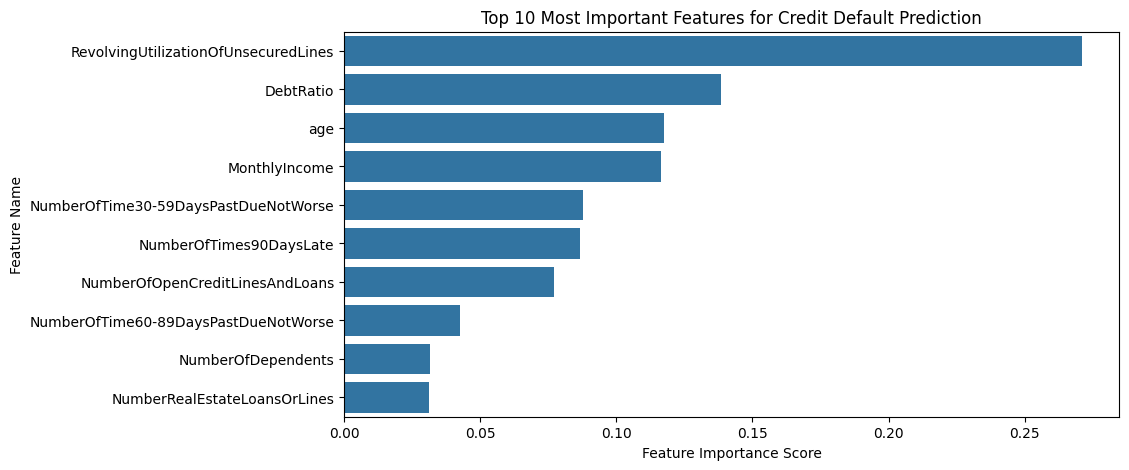

In [18]:
# Plot top 10 important features
top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Most Important Features for Credit Default Prediction")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature Name")
plt.show()

## 8. Prediction Decision

The model predicts the probability that a customer will default.

Decision rule:
- If probability is high, the customer is considered higher risk.
- If probability is low, the customer is considered lower risk.

This prediction can help banks review risky applications more carefully.

In [19]:
# Predict class labels for the test data
test_predictions = best_model.predict(X_test)

# Predict probabilities for default class
test_probabilities = best_model.predict_proba(X_test)[:, 1]

# Create submission-style DataFrame
predictions_df = pd.DataFrame({
    "Predicted_Default": test_predictions,
    "Default_Probability": test_probabilities
})

predictions_df.head()

,Predicted_Default,Default_Probability
0,0,0.01
1,0,0.04
2,0,0.00
3,0,0.04
4,0,0.23


In [20]:
# Save predictions to CSV file
predictions_df.to_csv("credit_default_predictions.csv", index=False)

In [21]:
# Save trained model
joblib.dump(best_model, "credit_default_model.pkl")

['credit_default_model.pkl']